### Initializations

In [1]:
import numpy as np

from matplotlib import pyplot as plt
%matplotlib inline

import pandas as pd

import os
homedir=os.getenv("HOME")

STARS DATA CAN BE FOUND AT 
https://docs.google.com/spreadsheets/d/13I5bpN2UufIJMLsddHXUuQ2DoOaUdUGwrspVezlakVY/edit?gid=21304074#gid=21304074

In [2]:
star_df = pd.read_csv('Stars.csv')

In [3]:
label_list=[]
for n in range(1,5):
    label_list.append(f'Prev {n}W Average')
features = ['World','Average','Data Points','Observed Variance','Week Number'] + label_list
star_df = star_df[features]

In [4]:
star_df = star_df.dropna()
star_df = star_df[(star_df['Observed Variance']!='#VALUE!') & (star_df['Observed Variance']!='0')]

In [5]:
wave_duration = 93  # minutes

### Some visual inspection...

In [29]:
good_flag = (star_df['Data Points']>2)

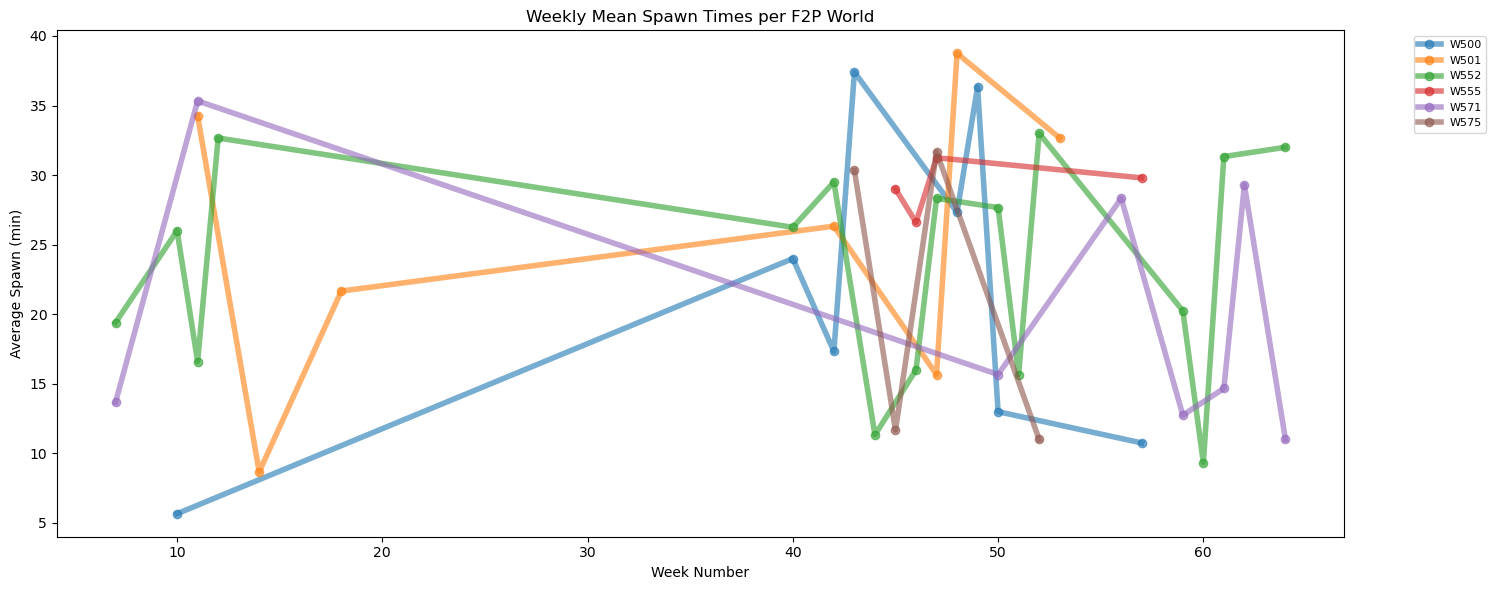

In [30]:
plt.figure(figsize=(15,6))

for world, sub in star_df[good_flag].groupby('World'):    
    
    if len(world)<4 and ('3' not in world and '4' not in world):
        plt.plot(sub['Week Number'], sub['Average'], marker='o', alpha=0.6, label=f"W{world}",lw=4)

plt.xlabel("Week Number")
plt.ylabel("Average Spawn (min)")
plt.title("Weekly Mean Spawn Times per F2P World")
#plt.xlim(40,)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### ...Moving from visual inspection to statistical testing

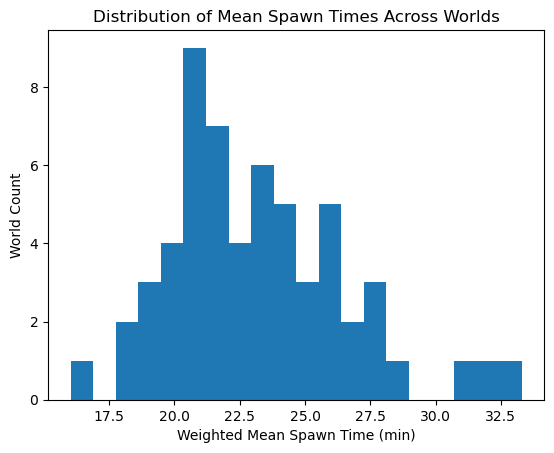

In [8]:
# Standard error per world-week
star_df['stderr'] = np.sqrt(star_df['Observed Variance'].astype(float) / star_df['Data Points'].astype(int))

# Weighted mean per world across all weeks
world_means = (star_df['Average'] / star_df['stderr']**2).groupby(star_df['World']).sum() / (1 / star_df['stderr']**2).groupby(star_df['World']).sum()

plt.hist(world_means, bins=20)
plt.xlabel('Weighted Mean Spawn Time (min)')
plt.ylabel('World Count')
plt.title('Distribution of Mean Spawn Times Across Worlds')
plt.show()


### Maybe ML...

In [17]:
%run run_simple_rfr.py

EXAMPLE:
run_all(df, clean=True, ndata_limit=3, world="301", feature_list=["Week Number"], test_size_=0.3)


<Figure size 640x480 with 0 Axes>

MSE: 115.598
R²: -0.518 (|R|: 0.719)


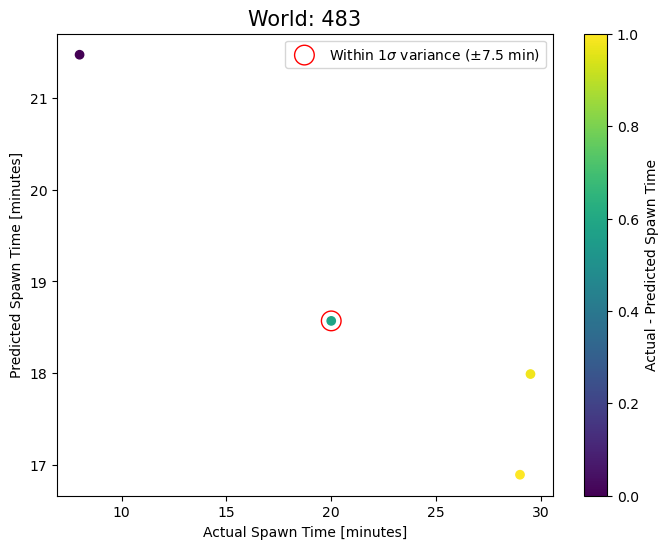

In [18]:
run_all(star_df, clean=False, feature_list=features, world=483, test_size_=0.2)

In [11]:
%run run_simple_rfc.py

EXAMPLE:
run_all(df, clean=True, ndata_limit=3, world="301",feature_list=["Week Number"], test_size_=0.3)


<Figure size 640x480 with 0 Axes>

In [12]:
label_list=[]
for n in range(1,4):
    label_list.append(f'Prev {n}W Average')
features = ['Week Number'] + label_list

Accuracy: 0.500
Weighted F1-score: 0.467

Classification Report:
              precision    recall  f1-score   support

       early       0.33      0.50      0.40         2
        late       0.00      0.00      0.00         1
         mid       0.67      0.67      0.67         3

    accuracy                           0.50         6
   macro avg       0.33      0.39      0.36         6
weighted avg       0.44      0.50      0.47         6



/Users/k215c316/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/k215c316/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/k215c316/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


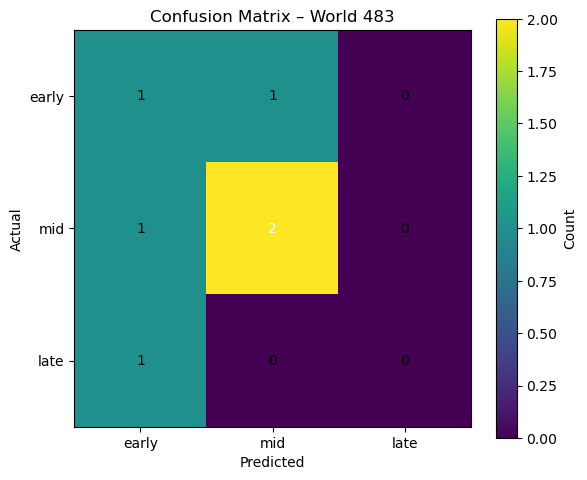

In [13]:
run_all(star_df, clean=False, world=483, test_size_=0.3, feature_list=features)

In [14]:
#need more data.

### SCRAP